### **Resumen Ejecutivo**

**Resumen Ejecutivo: Análisis de Rotación de Personal (HR Analytics)**
**Objetivo:** Identificar los factores críticos de deserción laboral para optimizar las políticas de retención y fortalecer la estabilidad organizacional.

*  **Estado Actual de la Fuerza Laboral**
Actualmente, la organización cuenta con una tasa de rotación global del 16.12%. El análisis comparativo de la base de datos (**1,233 empleados activos vs. 237 bajas**) arroja las siguientes dimensiones clave:

*  **Perfil de la Deserción:** El empleado promedio que abandona la compañía tiene **34 años**, una antigüedad de **5 años** y un ingreso mensual de **$4,787.**

*  **Perfil de Permanencia:** Los empleados que permanecen tienen una edad promedio mayor (**37-38 años**), una trayectoria más larga (**7 años**) y una compensación significativamente superior (**$6,832**).

**Hallazgos Estratégicos (Insights)**

* **Brecha Salarial como Factor Determinante:** Se identifica una disparidad salarial crítica en todos los departamentos. En **Recursos Humanos**, por ejemplo, quienes se van perciben casi la mitad del salario (**3,715**) en comparación con quienes se quedan (**$7,345**). Esta brecha no solo impulsa la rotación, sino que correlaciona con un nivel de satisfacción bajo (**2.46/4**)



*  **Carga de Trabajo y Horas Extra:** Existe una correlación directa entre la ejecución de horas extra y la decisión de abandonar la empresa. Los empleados que se retiran exceden significativamente la carga de trabajo de quienes permanecen, señalando una oportunidad crítica en la planificación y balanceo de cargas.

*  **Vulnerabilidad del Departamento de Ventas:** Con una tasa de rotación del **20.6%**, el área de Ventas es la de mayor riesgo. Esto sugiere que el modelo actual de alta presión/orientación a resultados está erosionando la estabilidad del equipo.

**Recomendaciones y Metas Propuestas**
*  **Política de Compensación:** Revisar la estructura salarial para reducir las brechas detectadas, asegurando que la compensación sea competitiva respecto a la retención de talento clave.

*  **Estrategia de Satisfacción:** El personal que permanece reporta una satisfacción promedio de **2.77/4**. Establecer como meta institucional superar el 3.0 en este índice es fundamental para mitigar la rotación futura y consolidar un equipo más comprometido.

*  **Balance de Carga:** Implementar un diagnóstico de carga operativa para reducir las horas extra excesivas, mitigando así el desgaste (burnout) prematuro del personal.

### **Conexión inicial**

In [ ]:
#Conexión con servidor SQL
import pandas as pd
import sqlite3

conn = sqlite3.connect(':memory:')

df_Hr   = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_Hr.to_sql('hr_data', conn, index=False, if_exists='replace')

1470

### **Validación de columnas**

In [ ]:
# Validación rápida y necesaria
print(df_Hr.shape)
print(df_Hr.dtypes)
print(df_Hr.isnull().sum())
print(df_Hr['Attrition'].value_counts())

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

**Insight identificado**

Se encuentra que hay **1233** empleados que **NO** se fueron, y **237** empleados que abandonarón la empresa

### **Calculo de la tasa de rotación**: Pandas vs SQL

In [ ]:
#En Pandas
(pd.crosstab(df_Hr['Department'], df_Hr['Attrition'], normalize='index') * 100.)



Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [ ]:
#En SQL
queryTasa = """
SELECT Department,
       (SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) as tasa_rotacion
FROM hr_data
GROUP BY Department;
"""
df_TasaRotacion = pd.read_sql_query(queryTasa, conn)
display(df_TasaRotacion)

,Department,tasa_rotacion
0,Human Resources,19.047619
1,Research & Development,13.839750
2,Sales,20.627803


In [ ]:
# --- Cálculo de la Tasa Global de Rotación ---
# Se utiliza el método 'value_counts(normalize=True)' para obtener la proporción
# de cada categoría en 'Attrition'. Multiplicamos por 100 para obtener el porcentaje.
tasa_global = df_Hr['Attrition'].value_counts(normalize=True)['Yes'] * 100

print(f"La tasa global de rotación es del {tasa_global:.2f}%")

La tasa global de rotación es del 16.12%


**Insight identificado**

Se observa que el departamento de **ventas** tiene la rotación más alta, con un **20.6%** representa un porcentaje significativo, lo cual tiene sentido por su constante enfoque orientado a resultados, y por lo estresante que puede ser para algunas personas manejar el estres por conseguir ventas, por lo que todos no soportan la carga, por otro lado se observa que el departamento de Investigación y desarrollo presenta la tasa de permanencia más alta con un **86.16%** lo que indica una satisfacción general de los trabajadores de este departamento, con su tasa de rotación del **13.83**, lo cual se debe indagar el motivo de ese porcentaje para tomar decisiones con base a la información

### **Perfil Comparativo**


In [ ]:
# Ejemplo de perfil comparativo
df_Hr.groupby('Attrition').agg({
    'Age': 'mean',
    'MonthlyIncome': 'mean',
    'YearsAtCompany': 'mean',
    'JobSatisfaction': 'mean',
    'OverTime': lambda x: (x == 'Yes').mean() * 100
})

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,OverTime
Attrition,,,,,
No,37.561233,6832.739659,7.369019,2.778589,23.438767
Yes,33.607595,4787.092827,5.130802,2.468354,53.586498


**Insight identificados**

Se observa que la edad promedio de trabajadores que abandonan la empresa es de **34 años**, y su promedio de ingresos mensuales es de **$4787.09** con una duración media en la compañía de **5 años**

Mientras que los trabajadores que permanecen en la empresa tienen una edad promedia de **37 años** con ingresos mensuales promedios de **$6832.73** con un promedio de **7 años** en la compañía. Es importante destacar que a pesar que estos trabajadores permanecen en la empresa, se debe trabajar en el indice de satisfacción, ya que en una escala de 1-4 tienen un promedio de **2.77**, por lo que podría ser una meta alcanzable superar por encima de 3 la satisfacción del trabajador para disminuir la tasa de rotación para consolidar uan estabilidad, y enfocarse en los resultados.

Se identifica que los que abandonarón, realizan más de **30. Horas** que los que permanecen en la empresa dejando ver una posible causal para abandonar la empresa, este resultado indica que se debe revisar la planificación para realizar un correcto balanceo de cargas.

### **Visualizaciones estrategicas**


/tmp/ipykernel_807/3642525816.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rotacion_depto.index, y=rotacion_depto.values, palette='viridis')


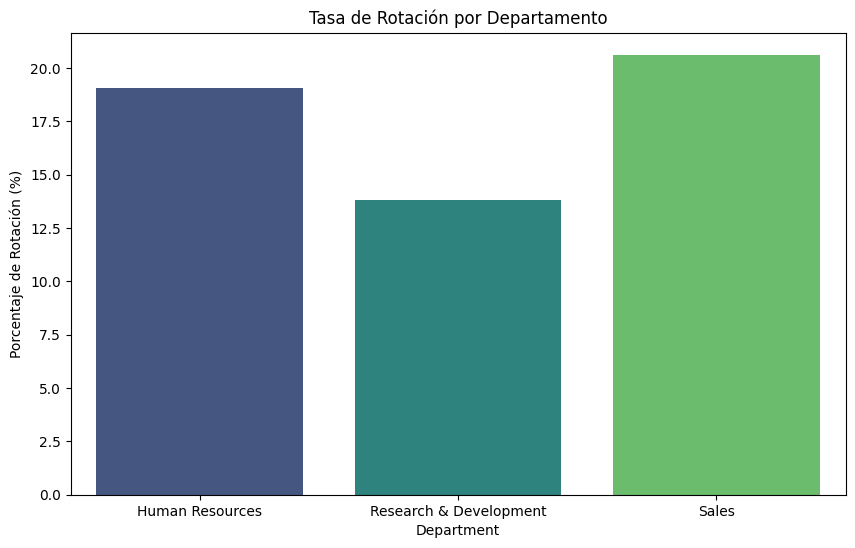

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la tasa por departamento para graficar
rotacion_depto = df_Hr.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(10,6))
sns.barplot(x=rotacion_depto.index, y=rotacion_depto.values, palette='viridis')
plt.title('Tasa de Rotación por Departamento')
plt.ylabel('Porcentaje de Rotación (%)')
# Comentario: Esta visualización permite identificar rápidamente qué áreas
# requieren intervención prioritaria en retención de talento.
plt.show()

 **Insighht Encontrado**

Se observa que la tasa de rotación por departamento más alta tal y cmo se comentó arriba es el departamento de ventas con un **20%** seguido de recursos humanos con aproximadamente un **19%**


In [25]:
# Cálculo de los valores para la pregunta de negocio
tabla_salarios = df_Hr.groupby(['Department', 'Attrition'])['MonthlyIncome'].mean().unstack()

# Esto imprimirá la tabla con los promedios exactos
print("Salario promedio por Departamento y Attrition:")
(tabla_salarios)

Salario promedio por Departamento y Attrition:


Attrition,No,Yes
Department,,
Human Resources,7345.980392,3715.750000
Research & Development,6630.326087,4108.075188
Sales,7232.240113,5908.456522


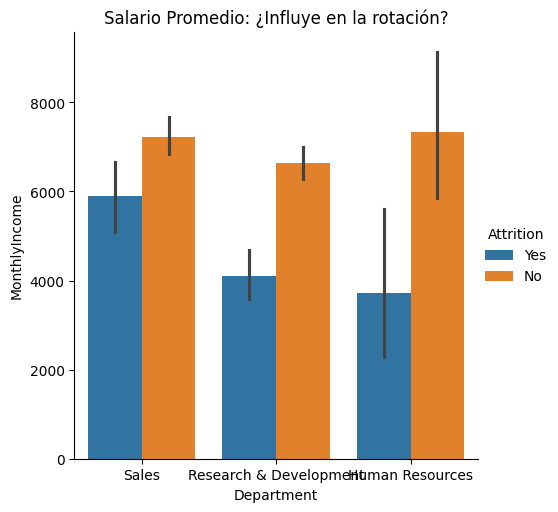

In [ ]:
# Usamos catplot para agrupar por departamento y comparar Attrition
sns.catplot(data=df_Hr, x='Department', y='MonthlyIncome', hue='Attrition', kind='bar')
plt.title('Salario Promedio: ¿Influye en la rotación?')
# Comentario: Permite observar si existe una brecha salarial significativa
# entre quienes permanecen y quienes deciden salir, lo cual es clave para el área de HR.
plt.show()

**Insight encontrado**

Se observa la brecha salarial de las personas que no permanecen en la empresa mediante el gráfico, siendo esta brecha más grande en Recursos Humanos, en donde se evidencia que tal brecha influye en la rotación.

### **Preguntas de negocio**



**Nivel 1**


La tasa global de rotación es de **16.12%** siendo el departamento de **ventas** tiene la rotación más alta, con un **20.6%** representa un porcentaje significativo, la edad promedio de los empleados de los que se van es de **34 años** mientras que los que se quedan es de **38 años**

**Nivel 2**

Los empleados que hacen horas extra tienen mayor tasa de rotación, el salario promedio de los que se quedan son los siguientes por departamento:


*  **Recursos humanos:** El salario promedio de los que se van, con respecto a los que se quedan es de aproximadamente **3715.75** y **$7345.95**

*  **Ventas:** El salario promedio de los que se van respecto a los que se quedan es de **$5908.45** y **$7232.24**

* **Investigación y desarrollo:** El salario promedio de los que se van respecto a los que se quedan es de **$4108.75** y **$6630.32**  

Esta información permite confirmar que la brecha salarial es muy alta lo que es un causal directo a la tasa de rotación de la empresa. Y hace que el nivel de satisfacción de los que se quedan no sea muy alto.

El nivel de satisfacción promedio de los que se fueron es de **2.46/4**


**Nivel 3**

Se observa que la edad promedio de trabajadores que abandonan la empresa es de **34 años**, y su promedio de ingresos mensuales es de **$4787.09** con una duración media en la compañía de **5 años**

Mientras que los trabajadores que permanecen en la empresa tienen una edad promedia de **37 años** con ingresos mensuales promedios de **$6832.73** con un promedio de **7 años** en la compañía. Es importante destacar que a pesar que estos trabajadores permanecen en la empresa, se debe trabajar en el indice de satisfacción, ya que en una escala de 1-4 tienen un promedio de **2.77**, por lo que podría ser una meta alcanzable superar por encima de 3 la satisfacción del trabajador para disminuir la tasa de rotación para consolidar uan estabilidad, y enfocarse en los resultados.

Se identifica que los que abandonarón, realizan un overtime de **53.6%** con respecto al **23.4%** permanecen en la empresa dejando ver una posible causal para abandonar la empresa, este resultado indica que se debe revisar la planificación para realizar un correcto balanceo de cargas.

### **Cosultas SQL**

In [26]:
# 1. Creamos el archivo y escribimos el contenido SQL
sql_content = """
-- Proyecto: HR Analytics - Análisis de Rotación
-- Autor: [Joshuar Rodriguez]

-- 1. Tasa de rotación global
SELECT
    (SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) as tasa_rotacion_global
FROM hr_data;

-- 2. Tasa de rotación por departamento
SELECT
    Department,
    (SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) as tasa_rotacion_depto
FROM hr_data
GROUP BY Department;

-- 3. Salario promedio por Departamento y Attrition
SELECT
    Department,
    Attrition,
    AVG(MonthlyIncome) as promedio_salario
FROM hr_data
GROUP BY Department, Attrition;

-- 4. Perfil comparativo (Age, Income, YearsAtCompany, JobSatisfaction)
-- Nota: La lógica de 'OverTime' como porcentaje se maneja con un CASE
SELECT
    Attrition,
    AVG(Age) as edad_promedio,
    AVG(MonthlyIncome) as salario_promedio,
    AVG(YearsAtCompany) as anios_empresa_promedio,
    AVG(JobSatisfaction) as satisfaccion_promedio,
    (SUM(CASE WHEN OverTime = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) as porcentaje_horas_extra
FROM hr_data
GROUP BY Attrition;
"""

with open('queries_hr.sql', 'w') as f:
    f.write(sql_content)

# 2. Descargamos el archivo directamente
from google.colab import files
files.download('queries_hr.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **PANDAS VS SQL**

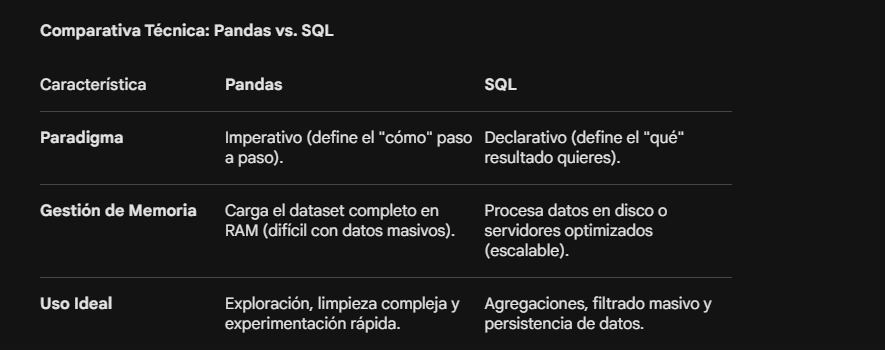

**Análisis de la Comparativa en el Proyecto**

*  Flexibilidad: En Pandas, el cálculo del porcentaje de rotación es altamente flexible, permitiéndonos realizar transformaciones complejas como el uso de lambda para el cálculo de horas extra en una sola línea. Sin embargo, esto depende totalmente de la capacidad de memoria de nuestra máquina.

*  Eficiencia: Por otro lado, al realizar la misma consulta en SQL mediante GROUP BY y SUM(CASE...), delegamos la carga computacional al motor de base de datos. Este enfoque es superior en entornos de producción, ya que minimiza la transferencia de datos y aprovecha la optimización de consultas del motor SQL, siendo el estándar de oro en la ingeniería de datos.

**Veredicto:**

**Para la etapa de exploración y hallazgo de insights rápidos, Pandas es insustituible por su capacidad de manipulación inmediata. No obstante, para estandarizar KPIs y reportes recurrentes a gran escala, la lógica en SQL es significativamente más eficiente y fácil de mantener en arquitecturas de datos empresariales.**